1.Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns # draw confusion matrix
import matplotlib.pyplot as plt # draw graphs
import numpy as np # do mathematical computations
import kagglehub # download dataset
import pandas as pd # process file path table
import os
from PIL import Image # read images
import torch.nn.functional as F

2.Check GPU

In [3]:
# Before running this notebook, enabling GPU.
# Runtime->Change runtime type->Hardware accelerator: T4 GPU->Save
# This is to shorten training time since we have a large dataset
# Check if GPU is available for faster training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


3.Download Dataset

In [4]:
# download CIFAKE dataset from Kaggle
# "CIFAKE is a dataset that contains 60,000 synthetically-generated images and 60,000 real images (collected from CIFAR-10)."
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)
# verify dataset structure
print(os.listdir(path))
# check labels
print(os.listdir(path+'/train'))

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Path to dataset files: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
['test', 'train']
['FAKE', 'REAL']


4.Build dataframe

In [11]:
# set up an empty list for collecting all image information
data=[]
# iterate through two folders 'test' and 'train'
for split in ['test','train']:
  # connect file path
  split_path=os.path.join(path,split)
  # check if the folder exists
  if os.path.exists(split_path):
    # iterate through 'FAKE' and 'REAL' subfolders
    for label in ['FAKE','REAL']:
      # connect file path
      label_path=os.path.join(split_path,label)
      # check if subfolders exist
      if os.path.exists(label_path):
        # scan all files in the folder
        with os.scandir(label_path) as entries:
          #iterate through all files
          for entry in entries:
            # make sure it only reads the image file
            if entry.is_file():
              data.append({
                  'file_path':entry.path, # file path
                  'label':1 if label=='FAKE' else 0, # FAKE=1 or REAL=0
                  'split':split # train or test
              })
# convert the file list into a table
df=pd.DataFrame(data)

print(f"Total images loaded: {len(df)}")
print(f"Train: {len(df[df['split']=='train'])}")
print(f"Test: {len(df[df['split']=='test'])}")
print(f"REAL: {len(df[df['label']==0])}")
print(f"FAKE: {len(df[df['label']==1])}")


Total images loaded: 120000
Train: 100000
Test: 20000
REAL: 60000
FAKE: 60000


5.Define a custom PyTorch Dataset

In [12]:
# referenced from PyTorch tutorial https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
class CIFAKEDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe) # the number of pictures in the dataset

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    image=Image.open(img_path).convert('RGB') # # open PIL Image (pic people see)
    label= self.dataframe.iloc[idx, 1] # 0=real, 1=fake
    if self.transform:
      image = self.transform(image) # transform PIL Image to tensor (numerical matrix)
    return image, label


6.Split into Train/Validation/Test sets

In [13]:
# Train: model learns from this data
# Validation: check performance during training to detect overfitting
# Test: final evaluation
# For this dataset, 80% of 'train' files are used for training; 20% of 'train' files are used for validation; all of 'test' files are used for testing

# shuffle train data and then seperate train and test
train=df[df['split']=='train'].sample(frac=1, random_state=42)
test=df[df['split']=='test']

# calculate split size
n_total=len(train)
n_train=int(0.8*n_total)
n_val=n_total-n_train

# slice into train and val
train_data=train[:n_train]
val_data=train[n_train:]

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test)}")


Train: 80000, Val: 20000, Test: 20000


7.Define transform

In [14]:
transform=transforms.Compose([
    transforms.ToTensor(), # convert PIL images into Tensor， ToTensor() converts pixel value into range 0-1
    transforms.Normalize(mean=[0.5,0.5,0.5], # the average of R,G,B
                         # the normalization formula: (pixel-mean)/std
                         # normalizing it into range (-1)-1 makes the data better for model training
                         std=[0.5,0.5,0.5]) # the standard deviation of R,B,G
])

8.Create datasets and dataloaders

In [15]:
# referenced from L6_PyTorch_Model_Doodle_Classifer
BATCH_SIZE=64

train_dataset=CIFAKEDataset(train_data, transform=transform)
val_dataset=CIFAKEDataset(val_data, transform=transform)
test_dataset=CIFAKEDataset(test, transform=transform)

# feed data to the model batch by batch
train_loader=DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=2) # shuffle=True prevents the model from remembering data sequence
val_loader=DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=2)# num_workers helps prepare next batch, more time-efficient
test_loader=DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=2)

# sanity check
images_batch, labels_batch = next(iter(train_loader))
print(f"One batch of images shape: {images_batch.shape}")
print(f"One batch of labels shape: {labels_batch.shape}")
print(f"Label examples: {labels_batch[:10]}")

One batch of images shape: torch.Size([64, 3, 32, 32])
One batch of labels shape: torch.Size([64])
Label examples: tensor([0, 0, 1, 1, 1, 1, 0, 1, 1, 0])


9.Build CNN model

In [16]:
# referenced from L6_PyTorch_Model_Doodle_Classifer
class CIFAKECNN(nn.Module):
  def __init__(self, labelnum=1):
    super(CIFAKECNN, self).__init__()

    # Block 1: 3 input channel->32 filters
    # formula: output_size=(input_size-kernel_size+2*padding)/stride+1
    # Input: (batch, 3, 32, 32)
    # After conv: (batch, 32, 30 ,30) <- (32-3+0)/1+1=30
    # After pool: (batch, 32, 15, 15) <- 30//2=15
    self.conv1=nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0)
    self.pool=nn.MaxPool2d(kernel_size=2, stride=2)

    # Block 2: 32->64 filters
    # Input: (batch, 32, 15, 15)
    # After conv: (batch, 64, 13, 13) <- (15-3+0)/1+1=13
    # After pool: (batch, 64, 6, 6) <- 13//2=6
    self.conv2=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0)

    # Block 3: 64->128 filters
    # Input: (batch, 64, 6, 6)
    # After conv: (batch, 128, 4, 4) <- (6-3+0)/1+1=4
    # After pool: (batch, 128, 2, 2) <- 4//2=2
    self.conv3=nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=0)

    # 128*2*2 is the size after 3 convolutions and poolings, output is 256 features
    self.fc1=nn.Linear(128*2*2, 256)
    # turns off 50% nuerons to prevent overfitting
    self.dropout=nn.Dropout(0.5)
    # turns 256 features into 1 output
    self.fc2=nn.Linear(256, labelnum)

  def forward(self, x):
    # Block 1
    x=self.pool(F.relu(self.conv1(x))) # relu removes useless negative values
    # Block 2
    x=self.pool(F.relu(self.conv2(x)))
    # Block 3
    x=self.pool(F.relu(self.conv3(x)))
    # Flatten
    x=x.view(x.size(0),-1)
    # Fully connected
    x=F.relu(self.fc1(x))
    x=self.dropout(x)
    x=torch.sigmoid(self.fc2(x)) # compress value into 0-1
    return x

# instantiate model and move to GPU
model=CIFAKECNN().to(device)
print(model)

CIFAKECNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)


10.Train the model

In [ ]:
# loss function and optimizer
criterion=nn.BCELoss() # evaluate how wrong the model is
optimizer=optim.Adam(model.parameters(), lr=0.001) # adjust parameters

In [11]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []} # Initialize history to store metrics

for epoch in range(10):
  model.train() # start training with dropout
  train_loss = 0
  train_correct = 0
  train_total = 0
  for batch_idx, (images, labels) in enumerate(train_loader): # take 64 images with label from train_loader every time
    images=images.to(device)
    labels=labels.to(device).float().unsqueeze(1) # Match output shape [batch_size, 1]
    # forward pass
    outputs=model(images) # feed images to the model and get predicted result (range from 0-1)
    # compute loss
    loss=criterion(outputs, labels)
    # backward pass
    optimizer.zero_grad() # clear the gradient of previous batch
    loss.backward() # calculate how each parameter should be adjusted
    # update weights
    optimizer.step()
    train_loss += loss.item() * images.size(0)
    train_correct += ((outputs>0.5).float() == labels).sum().item()
    train_total += labels.size(0)
  avg_train_loss = train_loss / train_total
  train_acc = 100 * train_correct / train_total

  # validation
  model.eval() # turn off dropout
  with torch.no_grad():
    # initialize three counters
    val_loss=0
    correct=0
    total=0
    for images, labels in val_loader:
      images=images.to(device)
      labels=labels.to(device).float().unsqueeze(1) # Match output shape [batch_size, 1]
      outputs=model(images)
      loss=criterion(outputs, labels)
      val_loss+=loss.item() * images.size(0) # cumulate loss
      # if >0.5-->Fake(1); otherwise Real(0)
      predicted=(outputs>0.5).float() # Predicted will also be [batch_size, 1]
      total+=labels.size(0) # Use labels.size(0) as it represents the batch size
      correct+=(predicted == labels).sum().item() # Correct comparison with labels of shape [batch_size, 1]
  average_loss=val_loss/total
  accuracy=100*correct/total

  # Store metrics
  history['train_loss'].append(avg_train_loss)
  history['train_acc'].append(train_acc)
  history['val_loss'].append(average_loss)
  history['val_acc'].append(accuracy)

  print(f"Epoch {epoch+1}/10 | Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_acc:.2f}% | Val Loss: {average_loss:.4f} | Val Accuracy: {accuracy:.2f}%") # Fix: use average_loss
print(f"Best validation accuracy: {max(history['val_acc']):.1f}%")

Epoch 1/10 | Train Loss: 0.3444 | Train Accuracy: 84.75% | Val Loss: 0.2439 | Val Accuracy: 90.04%
Epoch 2/10 | Train Loss: 0.2333 | Train Accuracy: 90.57% | Val Loss: 0.2695 | Val Accuracy: 89.03%
Epoch 3/10 | Train Loss: 0.1962 | Train Accuracy: 92.33% | Val Loss: 0.1848 | Val Accuracy: 92.83%
Epoch 4/10 | Train Loss: 0.1731 | Train Accuracy: 93.34% | Val Loss: 0.2076 | Val Accuracy: 91.70%
Epoch 5/10 | Train Loss: 0.1523 | Train Accuracy: 94.07% | Val Loss: 0.1656 | Val Accuracy: 93.58%
Epoch 6/10 | Train Loss: 0.1367 | Train Accuracy: 94.64% | Val Loss: 0.2003 | Val Accuracy: 92.23%
Epoch 7/10 | Train Loss: 0.1202 | Train Accuracy: 95.33% | Val Loss: 0.1894 | Val Accuracy: 93.30%
Epoch 8/10 | Train Loss: 0.1067 | Train Accuracy: 95.92% | Val Loss: 0.1715 | Val Accuracy: 93.69%
Epoch 9/10 | Train Loss: 0.0941 | Train Accuracy: 96.35% | Val Loss: 0.1779 | Val Accuracy: 93.72%
Epoch 10/10 | Train Loss: 0.0829 | Train Accuracy: 96.82% | Val Loss: 0.1816 | Val Accuracy: 93.69%
Best vali

11.Test evaluation

              precision    recall  f1-score   support

        REAL     0.9260    0.9492    0.9375     10000
        FAKE     0.9479    0.9242    0.9359     10000

    accuracy                         0.9367     20000
   macro avg     0.9370    0.9367    0.9367     20000
weighted avg     0.9370    0.9367    0.9367     20000



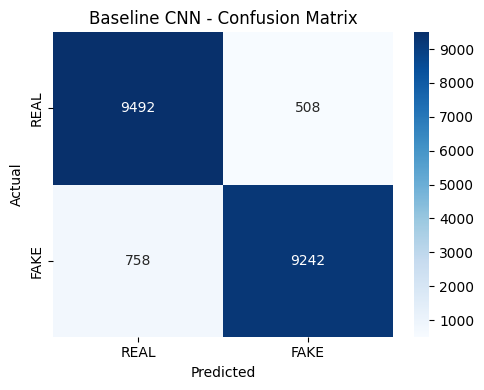

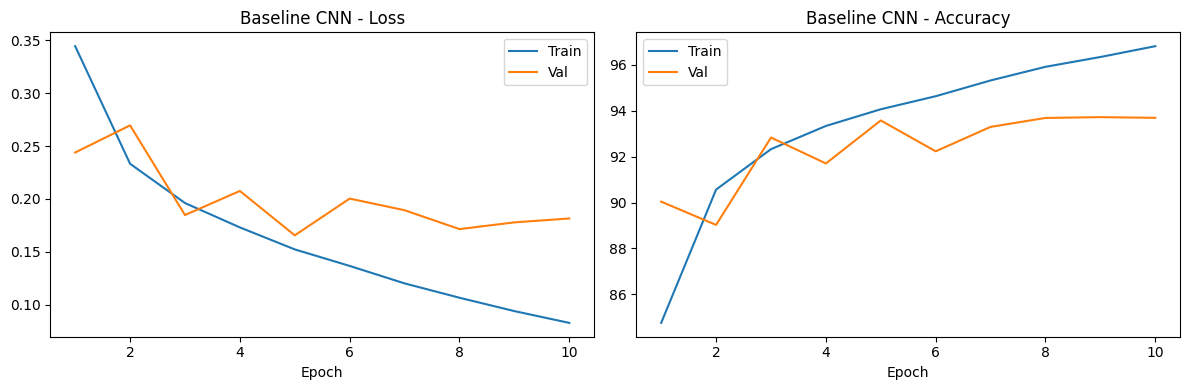

In [12]:
# Test set evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device).float().unsqueeze(1)
    outputs = model(images)
    predicted = (outputs > 0.5).float()
    all_preds.extend(predicted.squeeze(1).cpu().numpy())
    all_labels.extend(labels.squeeze(1).cpu().numpy())

# Print classification report
print(classification_report(all_labels, all_preds, target_names=['REAL', 'FAKE'], digits=4))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline CNN - Confusion Matrix')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

# Plot training curves
epochs = range(1, 11)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train')
plt.plot(epochs, history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.title('Baseline CNN - Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train')
plt.plot(epochs, history['val_acc'], label='Val')
plt.xlabel('Epoch')
plt.title('Baseline CNN - Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150)
plt.show()

12. Build ResNet-18 dataloaders

In [17]:
import torchvision.transforms as transforms
from torchvision import models

resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)), # ResNet expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # ImageNet stats
])

train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
val_size = int(0.1 * len(train_df))
val_df   = train_df[:val_size].reset_index(drop=True)
train_df = train_df[val_size:].reset_index(drop=True)

resnet_train_dataset = CIFAKEDataset(train_df, transform=resnet_transform)
resnet_val_dataset   = CIFAKEDataset(val_df,   transform=resnet_transform)
resnet_test_dataset  = CIFAKEDataset(test_df,  transform=resnet_transform)

resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=64, shuffle=True,  num_workers=2)
resnet_val_loader   = DataLoader(resnet_val_dataset,   batch_size=64, shuffle=False, num_workers=2)
resnet_test_loader  = DataLoader(resnet_test_dataset,  batch_size=64, shuffle=False, num_workers=2)

13. Build ResNet-18 Model

In [18]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in resnet_model.parameters():
    param.requires_grad = False # freeze all layers
resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 1),
    nn.Sigmoid()
)
resnet_model = resnet_model.to(device)
print(resnet_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]

Sequential(
  (0): Linear(in_features=512, out_features=1, bias=True)
  (1): Sigmoid()
)


14. Train ResNet-18

In [15]:
resnet_criterion = nn.BCELoss()
resnet_optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.001) # only train the last layer

resnet_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(10):
  resnet_model.train()
  train_loss = 0
  train_correct = 0
  train_total = 0
  for batch_idx, (images, labels) in enumerate(resnet_train_loader):
    images = images.to(device)
    labels = labels.to(device).float().unsqueeze(1)
    outputs = resnet_model(images)
    loss = resnet_criterion(outputs, labels)
    resnet_optimizer.zero_grad()
    loss.backward()
    resnet_optimizer.step()
    train_loss += loss.item() * images.size(0)
    train_correct += ((outputs > 0.5).float() == labels).sum().item()
    train_total += labels.size(0)
  avg_train_loss = train_loss / train_total
  train_acc = 100 * train_correct / train_total

  resnet_model.eval()
  with torch.no_grad():
    val_loss = 0
    correct = 0
    total = 0
    for images, labels in resnet_val_loader:
      images = images.to(device)
      labels = labels.to(device).float().unsqueeze(1)
      outputs = resnet_model(images)
      loss = resnet_criterion(outputs, labels)
      val_loss += loss.item() * images.size(0)
      predicted = (outputs > 0.5).float()
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  average_loss = val_loss / total
  accuracy = 100 * correct / total

  resnet_history['train_loss'].append(avg_train_loss)
  resnet_history['train_acc'].append(train_acc)
  resnet_history['val_loss'].append(average_loss)
  resnet_history['val_acc'].append(accuracy)

  print(f"Epoch {epoch+1}/10 | Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_acc:.2f}% | Val Loss: {average_loss:.4f} | Val Accuracy: {accuracy:.2f}%")

print(f"Best validation accuracy: {max(resnet_history['val_acc']):.1f}%")

Epoch 1/10 | Train Loss: 0.3515 | Train Accuracy: 84.89% | Val Loss: 0.3439 | Val Accuracy: 85.26%
Epoch 2/10 | Train Loss: 0.3031 | Train Accuracy: 87.07% | Val Loss: 0.2724 | Val Accuracy: 89.18%
Epoch 3/10 | Train Loss: 0.2957 | Train Accuracy: 87.44% | Val Loss: 0.2892 | Val Accuracy: 88.23%
Epoch 4/10 | Train Loss: 0.2924 | Train Accuracy: 87.61% | Val Loss: 0.3100 | Val Accuracy: 86.99%
Epoch 5/10 | Train Loss: 0.2892 | Train Accuracy: 87.80% | Val Loss: 0.3828 | Val Accuracy: 83.29%
Epoch 6/10 | Train Loss: 0.2908 | Train Accuracy: 87.66% | Val Loss: 0.2732 | Val Accuracy: 88.90%
Epoch 7/10 | Train Loss: 0.2882 | Train Accuracy: 87.76% | Val Loss: 0.3856 | Val Accuracy: 83.43%
Epoch 8/10 | Train Loss: 0.2866 | Train Accuracy: 87.92% | Val Loss: 0.3319 | Val Accuracy: 85.87%
Epoch 9/10 | Train Loss: 0.2879 | Train Accuracy: 87.86% | Val Loss: 0.2990 | Val Accuracy: 87.58%
Epoch 10/10 | Train Loss: 0.2857 | Train Accuracy: 87.93% | Val Loss: 0.2237 | Val Accuracy: 91.29%
Best vali

15. Test evaluation

              precision    recall  f1-score   support

        REAL     0.9074    0.8592    0.8826     10000
        FAKE     0.8663    0.9123    0.8887     10000

    accuracy                         0.8858     20000
   macro avg     0.8868    0.8858    0.8857     20000
weighted avg     0.8868    0.8858    0.8857     20000



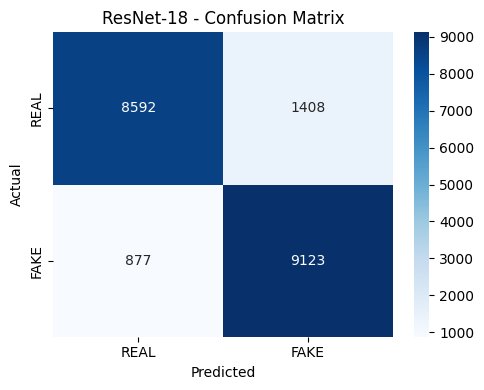

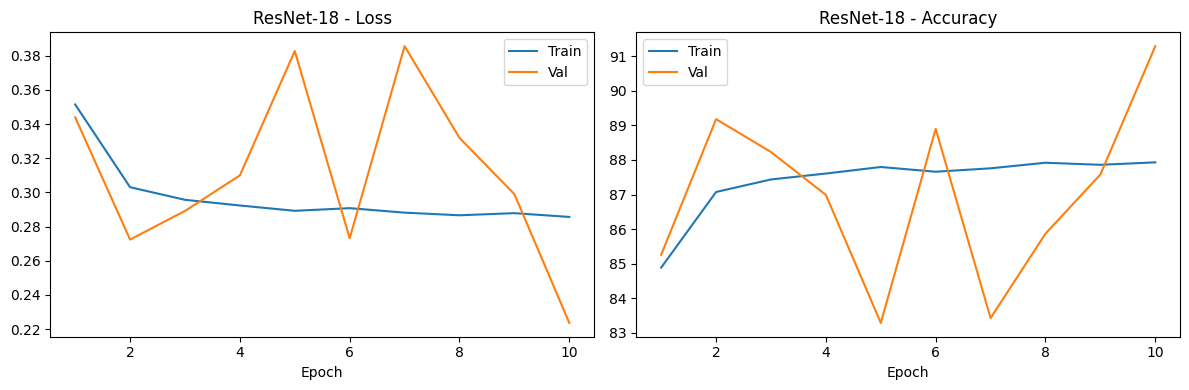

In [19]:
# Test set evaluation
resnet_model.eval()
resnet_all_preds = []
resnet_all_labels = []

with torch.no_grad():
  for images, labels in resnet_test_loader:
    images = images.to(device)
    labels = labels.to(device).float().unsqueeze(1)
    outputs = resnet_model(images)
    predicted = (outputs > 0.5).float()
    resnet_all_preds.extend(predicted.squeeze(1).cpu().numpy())
    resnet_all_labels.extend(labels.squeeze(1).cpu().numpy())

print(classification_report(resnet_all_labels, resnet_all_preds, target_names=['REAL', 'FAKE'], digits=4))

cm = confusion_matrix(resnet_all_labels, resnet_all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ResNet-18 - Confusion Matrix')
plt.tight_layout()
plt.savefig('resnet_confusion_matrix.png', dpi=150)
plt.show()

epochs_resnet = range(1, len(resnet_history['train_loss']) + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_resnet, resnet_history['train_loss'], label='Train')
plt.plot(epochs_resnet, resnet_history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.title('ResNet-18 - Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_resnet, resnet_history['train_acc'], label='Train')
plt.plot(epochs_resnet, resnet_history['val_acc'], label='Val')
plt.xlabel('Epoch')
plt.title('ResNet-18 - Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('resnet_training_curves.png', dpi=150)
plt.show()

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import json
torch.save(model.state_dict(), '/content/drive/MyDrive/cnn_model.pth')
torch.save(resnet_model.state_dict(), '/content/drive/MyDrive/resnet_model.pth')

with open('/content/drive/MyDrive/cnn_history.json', 'w') as f:
    json.dump(history, f)
with open('/content/drive/MyDrive/resnet_history.json', 'w') as f:
    json.dump(resnet_history, f)

print("Saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'history' is not defined

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import json

model = CIFAKECNN().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/cnn_model.pth'))

resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in resnet_model.parameters():
    param.requires_grad = False
resnet_model.fc = nn.Sequential(nn.Linear(512, 1), nn.Sigmoid())
resnet_model = resnet_model.to(device)
resnet_model.load_state_dict(torch.load('/content/drive/MyDrive/resnet_model.pth'))

# with open('/content/drive/MyDrive/cnn_history.json', 'r') as f:
#    history = json.load(f)
#with open('/content/drive/MyDrive/resnet_history.json', 'r') as f:
#    resnet_history = json.load(f)

print("Loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded successfully.


In [22]:
import shutil
shutil.copy('cnn_confusion_matrix.png', '/content/drive/MyDrive/cnn_confusion_matrix.png')
shutil.copy('cnn_training_curves.png', '/content/drive/MyDrive/cnn_training_curves.png')
shutil.copy('resnet_confusion_matrix.png', '/content/drive/MyDrive/resnet_confusion_matrix.png')
shutil.copy('resnet_training_curves.png', '/content/drive/MyDrive/resnet_training_curves.png')
print("Figures saved.")

Figures saved.


16. Find false-positive and false-negative images in test set

In [23]:
# Find misclassified images
resnet_model.eval()
fp_images = []  # False Positive: REAL predicted as FAKE
fn_images = []  # False Negative: FAKE predicted as REAL

with torch.no_grad():
    for images, labels in resnet_test_loader:
        images = images.to(device)
        labels = labels.to(device).float()
        outputs = resnet_model(images)
        preds = (outputs.squeeze(1) > 0.5).float()

        for i in range(len(labels)):
            pred = preds[i].item()
            actual = labels[i].item()

            if actual == 0 and pred == 1 and len(fp_images) < 3:
                fp_images.append(images[i].cpu())
            if actual == 1 and pred == 0 and len(fn_images) < 3:
                fn_images.append(images[i].cpu())

        if len(fp_images) >= 3 and len(fn_images) >= 3:
            break

print(f"Found {len(fp_images)} False Positives, {len(fn_images)} False Negatives")

Found 3 False Positives, 3 False Negatives


17. GradCAM Analysis

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


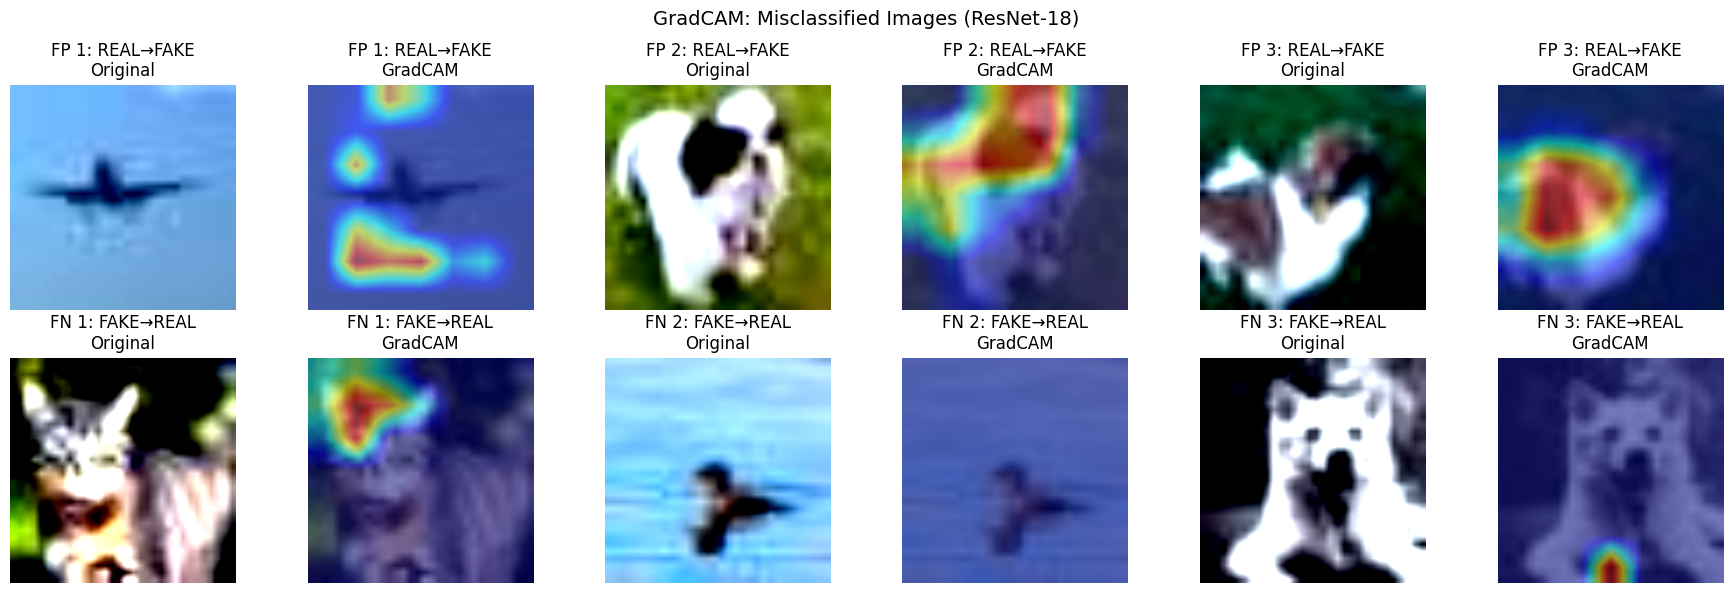

Saved gradcam_misclassified.png


In [24]:
import cv2
import numpy as np
from torchvision.transforms.functional import to_pil_image

# GradCAM for ResNet-18
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor):
        self.model.zero_grad()
        image_tensor = image_tensor.unsqueeze(0).to(device)
        image_tensor.requires_grad = True
        output = self.model(image_tensor)
        output.backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# initialize GradCAM on ResNet's last conv layer
grad_cam = GradCAM(resnet_model, resnet_model.layer4[1].conv2)

def overlay_heatmap(image_tensor, cam):
    # convert tensor to numpy image
    img = image_tensor.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)
    # resize cam to image size
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlaid = (0.5 * img + 0.5 * heatmap).astype(np.uint8)
    return overlaid

# Plot False Positives and False Negatives
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('GradCAM: Misclassified Images (ResNet-18)', fontsize=14)

for i in range(3):
    cam = grad_cam.generate(fp_images[i])
    overlaid = overlay_heatmap(fp_images[i], cam)
    axes[0, i*2].imshow(fp_images[i].permute(1,2,0).numpy() * 0.5 + 0.5)
    axes[0, i*2].set_title(f'FP {i+1}: REAL→FAKE\nOriginal')
    axes[0, i*2].axis('off')
    axes[0, i*2+1].imshow(overlaid)
    axes[0, i*2+1].set_title(f'FP {i+1}: REAL→FAKE\nGradCAM')
    axes[0, i*2+1].axis('off')

for i in range(3):
    cam = grad_cam.generate(fn_images[i])
    overlaid = overlay_heatmap(fn_images[i], cam)
    axes[1, i*2].imshow(fn_images[i].permute(1,2,0).numpy() * 0.5 + 0.5)
    axes[1, i*2].set_title(f'FN {i+1}: FAKE→REAL\nOriginal')
    axes[1, i*2].axis('off')
    axes[1, i*2+1].imshow(overlaid)
    axes[1, i*2+1].set_title(f'FN {i+1}: FAKE→REAL\nGradCAM')
    axes[1, i*2+1].axis('off')

plt.tight_layout()
plt.savefig('gradcam_misclassified.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved gradcam_misclassified.png")

In [26]:
from google.colab import files
files.download('gradcam_misclassified.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>